# Analyse des municipales 2014-2020-2026 et prédiction 2032

## Problématique
Prédire le taux de participation aux élections municipales de 2032 à partir des résultats 2014, 2020 et 2026, en tenant compte du caractère atypique de 2020 (Covid-19)

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
print("Bibliothèques prêtes.")

Bibliothèques prêtes.


## 2. Chargement des données brutes
Tous les fichiers sont dans `MsprData/data/`.  
Nous chargeons uniquement les colonnes nécessaires, avec `dtype=str` pour éviter les erreurs de conversion automatique.

In [227]:
data_path = "./data/"

# Élections
e2014 = pd.read_csv(data_path + "elections_2014.csv", sep=";", encoding="utf-8",
                    usecols=['CODDPT', 'CODSUBCOM', 'NBRINS', 'NBRVOT', 'NBREXP'],
                    dtype=str)
e2020 = pd.read_csv(data_path + "elections_2020.csv", sep=";", encoding="utf-8",
                    usecols=['Code du département', 'Code de la commune', 'Inscrits', 'Votants', 'Exprimés'],
                    dtype=str)
e2026 = pd.read_csv(data_path + "elections_2026.csv", sep=";", encoding="utf-8",
                    usecols=['Code département', 'Code commune', 'Inscrits', 'Votants', 'Exprimés'],
                    dtype=str)

# Données socio-économiques
chomage = pd.read_csv(data_path + "chomage.csv", sep=";")
populations = pd.read_csv(data_path + "population.csv", sep=";")
revenus = pd.read_csv(data_path + "revenus_pauvrete.csv", sep=";")
criminalite = pd.read_csv(data_path + "crimes_delits.csv", sep=";")

print("Fichiers chargés.")

Fichiers chargés.


In [186]:
import pandas as pd
import numpy as np

data_path = "./data/"

# Chargement avec low_memory=False pour éviter les warnings
e2014 = pd.read_csv(data_path + "elections_2014.csv", sep=";", encoding="utf-8", low_memory=False)
e2020 = pd.read_csv(data_path + "elections_2020.csv", sep=";", encoding="utf-8", low_memory=False)
e2026 = pd.read_csv(data_path + "elections_2026.csv", sep=";", encoding="utf-8", low_memory=False)

# Visualisation rapide
print("=== 2014 ===")
print("Dimensions :", e2014.shape)
display(e2014.head())

print("=== 2020 ===")
print("Dimensions :", e2020.shape)
display(e2020.head())

print("=== 2026 ===")
print("Dimensions :", e2026.shape)
display(e2026.head())

=== 2014 ===
Dimensions : (303165, 52)


,CODDPT,LIBDPT,CODSUBCOM,LIBSUBCOM,POPSUBCOM,NBRINS,NBRABS,PCTABSINS,NBRVOT,PCTVOTINS,NBRBLANUL,PCTBLNULINS,PCTBLNULVOT,NBREXP,PCTEXPINS,PCTEXPVOT,SEXPSN,NOMPSNEXT,PREPSN,ELU,NBRVOIX,PCTVOIXINS,PCTVOIXEXP,Date de l'export,Code du département,Type de scrutin,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs et nuls,% BlNuls/Ins,% BlNuls/Vot,Exprimés,% Exp/Ins,% Exp/Vot,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,Unnamed: 51
0,ZB,MARTINIQUE,208,Fonds-Saint-Denis,843.0,806.0,188.0,"23,32",618.0,"76,67",12.0,"1,48","1,94",606.0,"75,18","98,05",F,BOURGEOIS,Sandrine,Elu,415.0,"51,48","68,48",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ZB,MARTINIQUE,208,Fonds-Saint-Denis,843.0,806.0,188.0,"23,32",618.0,"76,67",12.0,"1,48","1,94",606.0,"75,18","98,05",M,BUSSY,Georges,Elu,415.0,"51,48","68,48",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ZB,MARTINIQUE,208,Fonds-Saint-Denis,843.0,806.0,188.0,"23,32",618.0,"76,67",12.0,"1,48","1,94",606.0,"75,18","98,05",F,DESPROL,Nadiège,Elu,415.0,"51,48","68,48",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ZB,MARTINIQUE,208,Fonds-Saint-Denis,843.0,806.0,188.0,"23,32",618.0,"76,67",12.0,"1,48","1,94",606.0,"75,18","98,05",M,EUGENE,Bonaventure,Elu,415.0,"51,48","68,48",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ZB,MARTINIQUE,208,Fonds-Saint-Denis,843.0,806.0,188.0,"23,32",618.0,"76,67",12.0,"1,48","1,94",606.0,"75,18","98,05",F,GABRIEL-REGIS,Aurelie,Elu,415.0,"51,48","68,48",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== 2020 ===
Dimensions : (34959, 31)


,Code du département,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,% Blancs/Ins,% Blancs/Vot,Nuls,% Nuls/Ins,% Nuls/Vot,Exprimés,% Exp/Ins,% Exp/Vot,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,Unnamed: 30
0,01,Ain,001,L'Abergement-Clémenciat,622,340,"54,66",282,"45,34",6,"0,96","2,13",2,"0,32","0,71",274,"44,05","97,16",2,NC,M,BOULON,Daniel,NaN,Oui,NaN,NaN,230,"36,98","83,94",NaN
1,01,Ain,002,L'Abergement-de-Varey,212,83,"39,15",129,"60,85",1,"0,47","0,78",1,"0,47","0,78",127,"59,91","98,45",2,NC,M,ORSET,Max,NaN,Oui,NaN,NaN,123,"58,02","96,85",NaN
2,01,Ain,006,Ambléon,107,42,"39,25",65,"60,75",0,"0,00","0,00",0,"0,00","0,00",65,"60,75","100,00",2,NC,F,BIONDA,Annie,NaN,Oui,NaN,NaN,43,"40,19","66,15",NaN
3,01,Ain,008,Ambutrix,547,188,"34,37",359,"65,63",6,"1,10","1,67",9,"1,65","2,51",344,"62,89","95,82",2,NC,M,JASPARD,Christian,NaN,NaN,NaN,NaN,166,"30,35","48,26",NaN
4,01,Ain,009,Andert-et-Condon,268,126,"47,01",142,"52,99",1,"0,37","0,70",2,"0,75","1,41",139,"51,87","97,89",2,NC,M,GUILLERMIN,Patrick,NaN,Oui,NaN,NaN,122,"45,52","87,77",NaN


=== 2026 ===
Dimensions : (34836, 187)


,Code département,Libellé département,Code commune,Libellé commune,Inscrits,Votants,% Votants,Abstentions,% Abstentions,Exprimés,% Exprimés/inscrits,% Exprimés/votants,Blancs,% Blancs/inscrits,% Blancs/votants,Nuls,% Nuls/inscrits,% Nuls/votants,Numéro de panneau 1,Nom candidat 1,Prénom candidat 1,Sexe candidat 1,Nuance liste 1,Libellé abrégé de liste 1,Libellé de liste 1,Voix 1,% Voix/inscrits 1,% Voix/exprimés 1,Elu 1,Sièges au CM 1,Sièges au CC 1,Numéro de panneau 2,Nom candidat 2,Prénom candidat 2,Sexe candidat 2,Nuance liste 2,Libellé abrégé de liste 2,Libellé de liste 2,Voix 2,% Voix/inscrits 2,% Voix/exprimés 2,Elu 2,Sièges au CM 2,Sièges au CC 2,Numéro de panneau 3,Nom candidat 3,Prénom candidat 3,Sexe candidat 3,Nuance liste 3,Libellé abrégé de liste 3,...,Prénom candidat 10,Sexe candidat 10,Nuance liste 10,Libellé abrégé de liste 10,Libellé de liste 10,Voix 10,% Voix/inscrits 10,% Voix/exprimés 10,Elu 10,Sièges au CM 10,Sièges au CC 10,Numéro de panneau 11,Nom candidat 11,Prénom candidat 11,Sexe candidat 11,Nuance liste 11,Libellé abrégé de liste 11,Libellé de liste 11,Voix 11,% Voix/inscrits 11,% Voix/exprimés 11,Elu 11,Sièges au CM 11,Sièges au CC 11,Numéro de panneau 12,Nom candidat 12,Prénom candidat 12,Sexe candidat 12,Nuance liste 12,Libellé abrégé de liste 12,Libellé de liste 12,Voix 12,% Voix/inscrits 12,% Voix/exprimés 12,Elu 12,Sièges au CM 12,Sièges au CC 12,Numéro de panneau 13,Nom candidat 13,Prénom candidat 13,Sexe candidat 13,Nuance liste 13,Libellé abrégé de liste 13,Libellé de liste 13,Voix 13,% Voix/inscrits 13,% Voix/exprimés 13,Elu 13,Sièges au CM 13,Sièges au CC 13
0,01,Ain,01001,L'Abergement-Clémenciat,679,374,"55,08%",305,"44,92%",345,"50,81%","92,25%",16,"2,36%","4,28%",13,"1,91%","3,48%",1.0,NaN,NaN,NaN,NaN,ENSEMBLE POUR L'ABERGEMENT CLEMENCIAT,ENSEMBLE POUR L'ABERGEMENT CLEMENCIAT,345,"50,81%","100,00%",NaN,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01,Ain,01002,L'Abergement-de-Varey,246,206,"83,74%",40,"16,26%",204,"82,93%","99,03%",1,"0,41%","0,49%",1,"0,41%","0,49%",1.0,NaN,NaN,NaN,NaN,ENSEMBLE POUR L'ABERGEMENT-DE-VAREY,ENSEMBLE POUR L'ABERGEMENT-DE-VAREY,114,"46,34%","55,88%",NaN,9,NaN,2.0,NaN,NaN,NaN,NaN,"NOTRE COMMUNE, NOTRE ENGAGEMENT","NOTRE COMMUNE, NOTRE ENGAGEMENT",90.0,"36,59%","44,12%",NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01,Ain,01004,Ambérieu-en-Bugey,8806,4286,"48,67%",4520,"51,33%",4081,"46,34%","95,22%",132,"1,50%","3,08%",73,"0,83%","1,70%",1.0,NaN,NaN,NaN,LDVG,AMBERIEU C'EST VOUS,AMBERIEU C'EST VOUS,1661,"18,86%","40,70%",NaN,7,3.0,2.0,NaN,NaN,NaN,LEXG,LUTTE OUVRIERE - LE CAMP DES TRAVAILLEURS,LUTTE OUVRIERE - LE CAMP DES TRAVAILLEURS,210.0,"2,38%","5,15%",NaN,0.0,0.0,3.0,NaN,NaN,NaN,LDVC,TOUS AMBARROIS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01,Ain,01005,Ambérieux-en-Dombes,1362,592,"43,47%",770,"56,53%",526,"38,62%","88,85%",43,"3,16%","7,26%",23,"1,69%","3,89%",1.0,NaN,NaN,NaN,NaN,"UNIS PAR NOTRE VILLAGE, ENGAGES POUR TOUS","UNIS PAR NOTRE VILLAGE, ENGAGES POUR TOUS",526,"38,62%","100,00%",NaN,19,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01,Ain,01006,Ambléon,107,93,"86,92%",14,"13,08%",90,"84,11%","96,77%",1,"0,93%","1,08%",

In [187]:
# 2014
e2014_clean = e2014.drop_duplicates(subset=['CODSUBCOM'], keep='first').copy()
e2014_clean.rename(columns={
    'CODSUBCOM': 'code_commune',
    'NBRINS': 'inscrits',
    'NBRVOT': 'votants',
    'NBREXP': 'exprimes'
}, inplace=True)
e2014_clean['code_commune'] = e2014_clean['code_commune'].astype(str).str.zfill(5)
e2014_clean['taux_participation'] = (e2014_clean['votants'] / e2014_clean['inscrits']) * 100
e2014_clean['annee'] = 2014

# Vérifie
print(e2014_clean.shape)
display(e2014_clean.head())

(930, 54)


,CODDPT,LIBDPT,code_commune,LIBSUBCOM,POPSUBCOM,inscrits,NBRABS,PCTABSINS,votants,PCTVOTINS,NBRBLANUL,PCTBLNULINS,PCTBLNULVOT,exprimes,PCTEXPINS,PCTEXPVOT,SEXPSN,NOMPSNEXT,PREPSN,ELU,NBRVOIX,PCTVOIXINS,PCTVOIXEXP,Date de l'export,Code du département,Type de scrutin,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs et nuls,% BlNuls/Ins,% BlNuls/Vot,Exprimés,% Exp/Ins,% Exp/Vot,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,Unnamed: 51,taux_participation,annee
0,ZB,MARTINIQUE,00208,Fonds-Saint-Denis,843.0,806.0,188.0,"23,32",618.0,"76,67",12.0,"1,48","1,94",606.0,"75,18","98,05",F,BOURGEOIS,Sandrine,Elu,415.0,"51,48","68,48",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.674938,2014
15,ZB,MARTINIQUE,00211,Grand'Rivière,567.0,823.0,142.0,"17,25",681.0,"82,74",12.0,"1,45","1,76",669.0,"81,28","98,23",M,AFRICA,Jocelyn,Elu,486.0,"59,05","72,64",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.746051,2014
30,ZC,GUYANE,00301,Régina,904.0,644.0,161.0,25,483.0,75,10.0,"1,55","2,07",473.0,"73,44","97,92",F,COVIS,Jocelyne,Elu,284.0,"44,09","60,04",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.000000,2014
34,ZC,GUYANE,00314,Ouanary,109.0,65.0,14.0,"21,53",51.0,"78,46",0.0,0,0,51.0,"78,46",100,F,BACK,Marthe,Elu,51.0,"78,46",100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.461538,2014
45,ZC,GUYANE,00352,Saül,153.0,131.0,34.0,"25,95",97.0,"74,04",4.0,"3,05","4,12",93.0,"70,99","95,87",M,BENOIT,Cedric,Elu,58.0,"44,27","62,36",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.045802,2014


In [188]:
# Cela signifie que la colonne CODSUBCOM n’est pas le code commune unique. 
# Dans mon fichier 2014, il y a probablement une autre colonne qui contient le vrai code 
# commune (sur 5 chiffres). L’extrait que j avais montré au début du projet 
# (avec Code du département et Code de la commune) correspond peut‑être à un autre fichier.

In [189]:
# Est‑ce normal d’avoir seulement 930 communes ?
# Non, la France compte environ 35 000 communes. 930 est anormalement faible.


# Verification 


In [190]:
# Compter le nombre de lignes dans le fichier CSV sans le charger complètement
import csv
with open(data_path + "elections_2014.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=';')
    lignes = sum(1 for _ in reader)
    print("Nombre total de lignes dans le fichier 2014 :", lignes)

Nombre total de lignes dans le fichier 2014 : 303166


In [191]:
e2014 = pd.read_csv(data_path + "elections_2014.csv", sep=";", encoding="utf-8",
                    usecols=['CODDPT', 'CODSUBCOM', 'NBRINS', 'NBRVOT', 'NBREXP'],
                    dtype=str)  # on garde tout en string pour éviter les problèmes

# Créer le code commune complet (5 chiffres pour la métropole, mais peut faire plus pour DOM)
e2014['code_commune'] = e2014['CODDPT'].str.strip() + e2014['CODSUBCOM'].str.strip()
# Pour les valeurs numériques, on convertit
e2014['inscrits'] = pd.to_numeric(e2014['NBRINS'], errors='coerce')
e2014['votants'] = pd.to_numeric(e2014['NBRVOT'], errors='coerce')
e2014['exprimes'] = pd.to_numeric(e2014['NBREXP'], errors='coerce')

# Supprimer les doublons sur code_commune
e2014_clean = e2014.drop_duplicates(subset=['code_commune'], keep='first').copy()
e2014_clean = e2014_clean[['code_commune', 'inscrits', 'votants', 'exprimes']]
e2014_clean['taux_participation'] = (e2014_clean['votants'] / e2014_clean['inscrits']) * 100
e2014_clean['annee'] = 2014

print("2014 :", e2014_clean.shape)
display(e2014_clean.head())
print("Nombre de communes uniques en 2014 :", e2014_clean['code_commune'].nunique())

2014 : (26745, 6)


,code_commune,inscrits,votants,exprimes,taux_participation,annee
0,ZB208,806.0,618.0,606.0,76.674938,2014
15,ZB211,823.0,681.0,669.0,82.746051,2014
30,ZC301,644.0,483.0,473.0,75.000000,2014
34,ZC314,65.0,51.0,51.0,78.461538,2014
45,ZC352,131.0,97.0,93.0,74.045802,2014


Nombre de communes uniques en 2014 : 26744


In [192]:
print("=== 2020 : colonnes et premiers codes ===")
print(e2020.columns.tolist())
print(e2020['Code de la commune'].head(10))

print("\n=== 2026 : colonnes et premiers codes ===")
print(e2026.columns.tolist())
print(e2026['Code commune'].head(10))

=== 2020 : colonnes et premiers codes ===
['Code du département', 'Libellé du département', 'Code de la commune', 'Libellé de la commune', 'Inscrits', 'Abstentions', '% Abs/Ins', 'Votants', '% Vot/Ins', 'Blancs', '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot', 'Exprimés', '% Exp/Ins', '% Exp/Vot', 'N.Pan.', 'Code Nuance', 'Sexe', 'Nom', 'Prénom', 'Liste', 'Sièges / Elu', 'Sièges Secteur', 'Sièges CC', 'Voix', '% Voix/Ins', '% Voix/Exp', 'Unnamed: 30']
0    001
1    002
2    006
3    008
4    009
5    011
6    012
7    013
8    015
9    016
Name: Code de la commune, dtype: object

=== 2026 : colonnes et premiers codes ===
['Code département', 'Libellé département', 'Code commune', 'Libellé commune', 'Inscrits', 'Votants', '% Votants', 'Abstentions', '% Abstentions', 'Exprimés', '% Exprimés/inscrits', '% Exprimés/votants', 'Blancs', '% Blancs/inscrits', '% Blancs/votants', 'Nuls', '% Nuls/inscrits', '% Nuls/votants', 'Numéro de panneau 1', 'Nom candidat 1', 'Prénom ca

In [193]:
e2020 = pd.read_csv(data_path + "elections_2020.csv", sep=";", encoding="utf-8",
                    usecols=['Code du département', 'Code de la commune', 'Inscrits', 'Votants', 'Exprimés'],
                    dtype=str)  # tout en string pour éviter les problèmes
print("2020 : colonnes et premiers codes après rechargement")
print(e2020.columns.tolist())
print(e2020['Code de la commune'].head(10))

2020 : colonnes et premiers codes après rechargement
['Code du département', 'Code de la commune', 'Inscrits', 'Votants', 'Exprimés']
0    001
1    002
2    006
3    008
4    009
5    011
6    012
7    013
8    015
9    016
Name: Code de la commune, dtype: object


In [194]:
# Créer le code commune complet (département + commune)
e2020['code_commune'] = e2020['Code du département'].str.strip() + e2020['Code de la commune'].str.strip()
e2020['inscrits'] = pd.to_numeric(e2020['Inscrits'], errors='coerce')
e2020['votants'] = pd.to_numeric(e2020['Votants'], errors='coerce')
e2020['exprimes'] = pd.to_numeric(e2020['Exprimés'], errors='coerce')

# Supprimer les doublons (une ligne par commune)
e2020_clean = e2020.drop_duplicates(subset=['code_commune'], keep='first').copy()
e2020_clean = e2020_clean[['code_commune', 'inscrits', 'votants', 'exprimes']]
e2020_clean['taux_participation'] = (e2020_clean['votants'] / e2020_clean['inscrits']) * 100
e2020_clean['annee'] = 2020

print("2020 nettoyé :", e2020_clean.shape)
display(e2020_clean.head())

2020 nettoyé : (34787, 6)


,code_commune,inscrits,votants,exprimes,taux_participation,annee
0,01001,622,282,274,45.337621,2020
1,01002,212,129,127,60.849057,2020
2,01006,107,65,65,60.747664,2020
3,01008,547,359,344,65.630713,2020
4,01009,268,142,139,52.985075,2020


In [195]:
e2026_clean = e2026.drop_duplicates(subset=['Code commune'], keep='first').copy()
e2026_clean.rename(columns={
    'Code commune': 'code_commune',
    'Inscrits': 'inscrits',
    'Votants': 'votants',
    'Exprimés': 'exprimes'
}, inplace=True)
e2026_clean['code_commune'] = e2026_clean['code_commune'].astype(str).str.zfill(5)
e2026_clean['taux_participation'] = (e2026_clean['votants'] / e2026_clean['inscrits']) * 100
e2026_clean['annee'] = 2026

print("2026 nettoyé :", e2026_clean.shape)
display(e2026_clean.head())

2026 nettoyé : (34836, 189)


,Code département,Libellé département,code_commune,Libellé commune,inscrits,votants,% Votants,Abstentions,% Abstentions,exprimes,% Exprimés/inscrits,% Exprimés/votants,Blancs,% Blancs/inscrits,% Blancs/votants,Nuls,% Nuls/inscrits,% Nuls/votants,Numéro de panneau 1,Nom candidat 1,Prénom candidat 1,Sexe candidat 1,Nuance liste 1,Libellé abrégé de liste 1,Libellé de liste 1,Voix 1,% Voix/inscrits 1,% Voix/exprimés 1,Elu 1,Sièges au CM 1,Sièges au CC 1,Numéro de panneau 2,Nom candidat 2,Prénom candidat 2,Sexe candidat 2,Nuance liste 2,Libellé abrégé de liste 2,Libellé de liste 2,Voix 2,% Voix/inscrits 2,% Voix/exprimés 2,Elu 2,Sièges au CM 2,Sièges au CC 2,Numéro de panneau 3,Nom candidat 3,Prénom candidat 3,Sexe candidat 3,Nuance liste 3,Libellé abrégé de liste 3,...,Nuance liste 10,Libellé abrégé de liste 10,Libellé de liste 10,Voix 10,% Voix/inscrits 10,% Voix/exprimés 10,Elu 10,Sièges au CM 10,Sièges au CC 10,Numéro de panneau 11,Nom candidat 11,Prénom candidat 11,Sexe candidat 11,Nuance liste 11,Libellé abrégé de liste 11,Libellé de liste 11,Voix 11,% Voix/inscrits 11,% Voix/exprimés 11,Elu 11,Sièges au CM 11,Sièges au CC 11,Numéro de panneau 12,Nom candidat 12,Prénom candidat 12,Sexe candidat 12,Nuance liste 12,Libellé abrégé de liste 12,Libellé de liste 12,Voix 12,% Voix/inscrits 12,% Voix/exprimés 12,Elu 12,Sièges au CM 12,Sièges au CC 12,Numéro de panneau 13,Nom candidat 13,Prénom candidat 13,Sexe candidat 13,Nuance liste 13,Libellé abrégé de liste 13,Libellé de liste 13,Voix 13,% Voix/inscrits 13,% Voix/exprimés 13,Elu 13,Sièges au CM 13,Sièges au CC 13,taux_participation,annee
0,01,Ain,01001,L'Abergement-Clémenciat,679,374,"55,08%",305,"44,92%",345,"50,81%","92,25%",16,"2,36%","4,28%",13,"1,91%","3,48%",1.0,NaN,NaN,NaN,NaN,ENSEMBLE POUR L'ABERGEMENT CLEMENCIAT,ENSEMBLE POUR L'ABERGEMENT CLEMENCIAT,345,"50,81%","100,00%",NaN,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.081001,2026
1,01,Ain,01002,L'Abergement-de-Varey,246,206,"83,74%",40,"16,26%",204,"82,93%","99,03%",1,"0,41%","0,49%",1,"0,41%","0,49%",1.0,NaN,NaN,NaN,NaN,ENSEMBLE POUR L'ABERGEMENT-DE-VAREY,ENSEMBLE POUR L'ABERGEMENT-DE-VAREY,114,"46,34%","55,88%",NaN,9,NaN,2.0,NaN,NaN,NaN,NaN,"NOTRE COMMUNE, NOTRE ENGAGEMENT","NOTRE COMMUNE, NOTRE ENGAGEMENT",90.0,"36,59%","44,12%",NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.739837,2026
2,01,Ain,01004,Ambérieu-en-Bugey,8806,4286,"48,67%",4520,"51,33%",4081,"46,34%","95,22%",132,"1,50%","3,08%",73,"0,83%","1,70%",1.0,NaN,NaN,NaN,LDVG,AMBERIEU C'EST VOUS,AMBERIEU C'EST VOUS,1661,"18,86%","40,70%",NaN,7,3.0,2.0,NaN,NaN,NaN,LEXG,LUTTE OUVRIERE - LE CAMP DES TRAVAILLEURS,LUTTE OUVRIERE - LE CAMP DES TRAVAILLEURS,210.0,"2,38%","5,15%",NaN,0.0,0.0,3.0,NaN,NaN,NaN,LDVC,TOUS AMBARROIS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.671360,2026
3,01,Ain,01005,Ambérieux-en-Dombes,1362,592,"43,47%",770,"56,53%",526,"38,62%","88,85%",43,"3,16%","7,26%",23,"1,69%","3,89%",1.0,NaN,NaN,NaN,NaN,"UNIS PAR NOTRE VILLAGE, ENGAGES POUR TOUS","UNIS PAR NOTRE VILLAGE, ENGAGES POUR TOUS",526,"38,62%","100,00%",NaN,19,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.465492,2026
4,01,Ain,01006,Ambléon,107,93,"86,92%",14,"13,08%",90,"84,11%","96,77%",1

In [196]:
print(e2026.columns.tolist())
print(e2026[['Code département', 'Code commune', 'Inscrits', 'Votants', 'Exprimés']].head())

['Code département', 'Libellé département', 'Code commune', 'Libellé commune', 'Inscrits', 'Votants', '% Votants', 'Abstentions', '% Abstentions', 'Exprimés', '% Exprimés/inscrits', '% Exprimés/votants', 'Blancs', '% Blancs/inscrits', '% Blancs/votants', 'Nuls', '% Nuls/inscrits', '% Nuls/votants', 'Numéro de panneau 1', 'Nom candidat 1', 'Prénom candidat 1', 'Sexe candidat 1', 'Nuance liste 1', 'Libellé abrégé de liste 1', 'Libellé de liste 1', 'Voix 1', '% Voix/inscrits 1', '% Voix/exprimés 1', 'Elu 1', 'Sièges au CM 1', 'Sièges au CC 1', 'Numéro de panneau 2', 'Nom candidat 2', 'Prénom candidat 2', 'Sexe candidat 2', 'Nuance liste 2', 'Libellé abrégé de liste 2', 'Libellé de liste 2', 'Voix 2', '% Voix/inscrits 2', '% Voix/exprimés 2', 'Elu 2', 'Sièges au CM 2', 'Sièges au CC 2', 'Numéro de panneau 3', 'Nom candidat 3', 'Prénom candidat 3', 'Sexe candidat 3', 'Nuance liste 3', 'Libellé abrégé de liste 3', 'Libellé de liste 3', 'Voix 3', '% Voix/inscrits 3', '% Voix/exprimés 3', 'Elu

In [197]:
#  Étape 5 : Concaténer les trois années
elections = pd.concat([e2014_clean, e2020_clean, e2026_clean], ignore_index=True)
print("Panel final :", elections.shape)
elections.to_csv("dataset_final.csv", index=False, sep=";")

Panel final : (96368, 189)


In [198]:
# Un DataFrame elections avec les colonnes : code_commune, inscrits, votants, exprimes, taux_participation, annee.

# Une ligne par commune et par année.

# Possibilité de passer aux jointures avec les données socio‑économiques (population, chômage, etc.)

In [199]:
# 🔧 Problème : ta table 2020 ne contient pas le code département actuellement
# Créer le code commune complet (département + commune)
e2020['code_commune'] = e2020['Code du département'].str.strip() + e2020['Code de la commune'].str.strip()
e2020['inscrits'] = pd.to_numeric(e2020['Inscrits'], errors='coerce')
e2020['votants'] = pd.to_numeric(e2020['Votants'], errors='coerce')
e2020['exprimes'] = pd.to_numeric(e2020['Exprimés'], errors='coerce')

# Supprimer les doublons (une ligne par commune)
e2020_clean = e2020.drop_duplicates(subset=['code_commune'], keep='first').copy()
e2020_clean = e2020_clean[['code_commune', 'inscrits', 'votants', 'exprimes']]
e2020_clean['taux_participation'] = (e2020_clean['votants'] / e2020_clean['inscrits']) * 100
e2020_clean['annee'] = 2020

print("2020 nettoyé :", e2020_clean.shape)
display(e2020_clean.head())

2020 nettoyé : (34787, 6)


,code_commune,inscrits,votants,exprimes,taux_participation,annee
0,01001,622,282,274,45.337621,2020
1,01002,212,129,127,60.849057,2020
2,01006,107,65,65,60.747664,2020
3,01008,547,359,344,65.630713,2020
4,01009,268,142,139,52.985075,2020


In [200]:
print("2014 :", e2014_clean['code_commune'].nunique())
print("2020 :", e2020_clean['code_commune'].nunique())
print("2026 :", e2026_clean['code_commune'].nunique())

2014 : 26744
2020 : 34787
2026 : 34836


In [201]:
# Recharger juste une ligne pour voir les colonnes (sans usecols)
sample_2026 = pd.read_csv(data_path + "elections_2026.csv", sep=";", encoding="utf-8", nrows=0)
print(sample_2026.columns.tolist())

['Code département', 'Libellé département', 'Code commune', 'Libellé commune', 'Inscrits', 'Votants', '% Votants', 'Abstentions', '% Abstentions', 'Exprimés', '% Exprimés/inscrits', '% Exprimés/votants', 'Blancs', '% Blancs/inscrits', '% Blancs/votants', 'Nuls', '% Nuls/inscrits', '% Nuls/votants', 'Numéro de panneau 1', 'Nom candidat 1', 'Prénom candidat 1', 'Sexe candidat 1', 'Nuance liste 1', 'Libellé abrégé de liste 1', 'Libellé de liste 1', 'Voix 1', '% Voix/inscrits 1', '% Voix/exprimés 1', 'Elu 1', 'Sièges au CM 1', 'Sièges au CC 1', 'Numéro de panneau 2', 'Nom candidat 2', 'Prénom candidat 2', 'Sexe candidat 2', 'Nuance liste 2', 'Libellé abrégé de liste 2', 'Libellé de liste 2', 'Voix 2', '% Voix/inscrits 2', '% Voix/exprimés 2', 'Elu 2', 'Sièges au CM 2', 'Sièges au CC 2', 'Numéro de panneau 3', 'Nom candidat 3', 'Prénom candidat 3', 'Sexe candidat 3', 'Nuance liste 3', 'Libellé abrégé de liste 3', 'Libellé de liste 3', 'Voix 3', '% Voix/inscrits 3', '% Voix/exprimés 3', 'Elu

In [202]:
e2026 = pd.read_csv(data_path + "elections_2026.csv", sep=";", encoding="utf-8",
                    usecols=['Code département', 'Code commune', 'Inscrits', 'Votants', 'Exprimés'],
                    dtype=str)
print(e2026.columns.tolist())

['Code département', 'Code commune', 'Inscrits', 'Votants', 'Exprimés']


In [203]:
# Créer le code commune complet (département + commune)
e2026['code_commune'] = e2026['Code département'].str.strip() + e2026['Code commune'].str.strip()
e2026['inscrits'] = pd.to_numeric(e2026['Inscrits'], errors='coerce')
e2026['votants'] = pd.to_numeric(e2026['Votants'], errors='coerce')
e2026['exprimes'] = pd.to_numeric(e2026['Exprimés'], errors='coerce')

# Supprimer les doublons (une ligne par commune)
e2026_clean = e2026.drop_duplicates(subset=['code_commune'], keep='first').copy()
e2026_clean = e2026_clean[['code_commune', 'inscrits', 'votants', 'exprimes']]
e2026_clean['taux_participation'] = (e2026_clean['votants'] / e2026_clean['inscrits']) * 100
e2026_clean['annee'] = 2026

print("2026 nettoyé :", e2026_clean.shape)
display(e2026_clean.head())


# Vérifier le nombre de communes uniques

print("Nombre de communes en 2026 :", e2026_clean['code_commune'].nunique())

2026 nettoyé : (34836, 6)


,code_commune,inscrits,votants,exprimes,taux_participation,annee
0,0101001,679,374,345,55.081001,2026
1,0101002,246,206,204,83.739837,2026
2,0101004,8806,4286,4081,48.671360,2026
3,0101005,1362,592,526,43.465492,2026
4,0101006,107,93,90,86.915888,2026


Nombre de communes en 2026 : 34836


In [204]:
# 2026 – correction du code commune
e2026 = pd.read_csv(data_path + "elections_2026.csv", sep=";", encoding="utf-8",
                    usecols=['Code département', 'Code commune', 'Inscrits', 'Votants', 'Exprimés'],
                    dtype=str)

e2026['dep'] = e2026['Code département'].str.strip().str.zfill(2)
e2026['com'] = e2026['Code commune'].str.strip().str[-3:]  # prend les 3 derniers caractères
e2026['code_commune'] = e2026['dep'] + e2026['com']

e2026['inscrits'] = pd.to_numeric(e2026['Inscrits'], errors='coerce')
e2026['votants'] = pd.to_numeric(e2026['Votants'], errors='coerce')
e2026['exprimes'] = pd.to_numeric(e2026['Exprimés'], errors='coerce')

e2026_clean = e2026.drop_duplicates(subset=['code_commune'], keep='first').copy()
e2026_clean = e2026_clean[['code_commune', 'inscrits', 'votants', 'exprimes']]
e2026_clean['taux_participation'] = (e2026_clean['votants'] / e2026_clean['inscrits']) * 100
e2026_clean['annee'] = 2026

print("2026 nettoyé (corrigé) :", e2026_clean.shape)
display(e2026_clean.head())
print("Exemples codes :", e2026_clean['code_commune'].head(5).tolist())

2026 nettoyé (corrigé) : (34836, 6)


,code_commune,inscrits,votants,exprimes,taux_participation,annee
0,01001,679,374,345,55.081001,2026
1,01002,246,206,204,83.739837,2026
2,01004,8806,4286,4081,48.671360,2026
3,01005,1362,592,526,43.465492,2026
4,01006,107,93,90,86.915888,2026


Exemples codes : ['01001', '01002', '01004', '01005', '01006']


In [205]:
# Après correction de e2026_clean, refaire l'intersection
communes_2014 = set(e2014_clean['code_commune'])
communes_2020 = set(e2020_clean['code_commune'])
communes_2026 = set(e2026_clean['code_commune'])
communes_communes = communes_2014.intersection(communes_2020).intersection(communes_2026)
print("Communes communes :", len(communes_communes))

e2014_final = e2014_clean[e2014_clean['code_commune'].isin(communes_communes)]
e2020_final = e2020_clean[e2020_clean['code_commune'].isin(communes_communes)]
e2026_final = e2026_clean[e2026_clean['code_commune'].isin(communes_communes)]

elections = pd.concat([e2014_final, e2020_final, e2026_final], ignore_index=True)
print("Panel final :", elections.shape)  # devrait être (n*3, 6)

Communes communes : 24789
Panel final : (74367, 6)


In [206]:
# Recalcul de l'intersection des codes communs (24 789 communes)
communes_2014 = set(e2014_clean['code_commune'])
communes_2020 = set(e2020_clean['code_commune'])
communes_2026 = set(e2026_clean['code_commune'])
communes_communes = communes_2014.intersection(communes_2020).intersection(communes_2026)
print("Communes communes :", len(communes_communes))

e2014_final = e2014_clean[e2014_clean['code_commune'].isin(communes_communes)]
e2020_final = e2020_clean[e2020_clean['code_commune'].isin(communes_communes)]
e2026_final = e2026_clean[e2026_clean['code_commune'].isin(communes_communes)]

elections = pd.concat([e2014_final, e2020_final, e2026_final], ignore_index=True)
print("Panel final restauré :", elections.shape)  # (74367, 6)
display(elections.head())

Communes communes : 24789
Panel final restauré : (74367, 6)


,code_commune,inscrits,votants,exprimes,taux_participation,annee
0,01001,599.0,355.0,341.0,59.265442,2014
1,01002,226.0,189.0,188.0,83.628319,2014
2,01006,107.0,69.0,66.0,64.485981,2014
3,01008,575.0,349.0,337.0,60.695652,2014
4,01009,259.0,179.0,176.0,69.111969,2014


In [228]:
# 1. Nettoyage des tables socio-économiques (identique à avant)
pop = populations[['code_commune', 'population_totale']].copy()
pop.rename(columns={'population_totale': 'population'}, inplace=True)
pop['code_commune'] = pop['code_commune'].astype(str).str.zfill(5)
pop = pop.drop_duplicates(subset='code_commune', keep='first')

chom = chomage.copy()
chom['code_commune'] = chom['code_commune'].astype(str).str.zfill(5)
chom = chom.sort_values('annee', ascending=False).groupby('code_commune', as_index=False).first()
chom = chom[['code_commune', 'taux_chomage']]

rev = revenus[['code_commune', 'revenu_median']].copy()
rev['code_commune'] = rev['code_commune'].astype(str).str.zfill(5)
rev = rev.drop_duplicates(subset='code_commune', keep='first')

crim = criminalite.copy()
crim['code_commune'] = crim['code_commune'].astype(str).str.zfill(5)
crim = crim.sort_values('annee_source', ascending=False).groupby('code_commune', as_index=False).first()
crim = crim[['code_commune', 'taux_criminalite']]

# Jointures (le left join conserve les 74367 lignes)
elections = elections.merge(pop, on='code_commune', how='left')
elections = elections.merge(chom, on='code_commune', how='left')
elections = elections.merge(rev, on='code_commune', how='left')
elections = elections.merge(crim, on='code_commune', how='left')

print("Après jointures :", elections.shape)  # doit être (74367, 10 ou 11)

Après jointures : (74367, 10)


In [208]:
# Vérifions que elections est toujours correct
print("Taille de elections avant jointures :", elections.shape)  # doit être (74367, 6)
display(elections.head())

Taille de elections avant jointures : (74367, 10)


,code_commune,inscrits,votants,exprimes,taux_participation,annee,population,taux_chomage,revenu_median,taux_criminalite
0,01001,599.0,355.0,341.0,59.265442,2014,779.0,6.636156,23970.0,0.0000
1,01002,226.0,189.0,188.0,83.628319,2014,256.0,1.470588,23640.0,0.0000
2,01006,107.0,69.0,66.0,64.485981,2014,112.0,9.615385,NaN,0.0000
3,01008,575.0,349.0,337.0,60.695652,2014,762.0,4.684074,25450.0,2.3026
4,01009,259.0,179.0,176.0,69.111969,2014,326.0,2.274224,23790.0,0.0000


In [209]:
# Après avoir créé elections avec la concaténation ci-dessus (74367, 6)
# Sauvegardez-le proprement (écrasez l’ancien)
elections.to_csv("dataset_final.csv", index=False, sep=";")
print("Nouveau dataset_final.csv sauvegardé.")

# Maintenant, vous pouvez continuer avec elections (ne pas le relire)
# Passez directement aux jointures socio-économiques, etc.

Nouveau dataset_final.csv sauvegardé.


In [210]:
print(elections.shape)  # doit afficher (74367, 6)
print(elections.head())

(74367, 10)
  code_commune  inscrits  votants  exprimes  taux_participation  annee  \
0        01001     599.0    355.0     341.0           59.265442   2014   
1        01002     226.0    189.0     188.0           83.628319   2014   
2        01006     107.0     69.0      66.0           64.485981   2014   
3        01008     575.0    349.0     337.0           60.695652   2014   
4        01009     259.0    179.0     176.0           69.111969   2014   

   population  taux_chomage  revenu_median  taux_criminalite  
0       779.0      6.636156        23970.0            0.0000  
1       256.0      1.470588        23640.0            0.0000  
2       112.0      9.615385            NaN            0.0000  
3       762.0      4.684074        25450.0            2.3026  
4       326.0      2.274224        23790.0            0.0000  


In [211]:
# Gestion des valeurs manquantes (NaN)
# Vérifier les NaN
print(elections.isna().sum())

# Abandonner taux_pauvrete si présent (trop de NaN)
if 'taux_pauvrete' in elections.columns:
    elections.drop(columns=['taux_pauvrete'], inplace=True)

# Imputer revenu_median par la médiane nationale
revenu_med = elections['revenu_median'].median()
elections['revenu_median'].fillna(revenu_med, inplace=True)

# Supprimer les quelques lignes où population manque
elections.dropna(subset=['population'], inplace=True)

print(elections.isna().sum())

code_commune              0
inscrits                  0
votants                   0
exprimes                  0
taux_participation        0
annee                     0
population                3
taux_chomage              0
revenu_median         10497
taux_criminalite          0
dtype: int64
code_commune          0
inscrits              0
votants               0
exprimes              0
taux_participation    0
annee                 0
population            0
taux_chomage          0
revenu_median         0
taux_criminalite      0
dtype: int64


/var/folders/4z/clf7bjsj3n3ft0f8p606btyw0000gn/T/ipykernel_1106/3677787607.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  elections['revenu_median'].fillna(revenu_med, inplace=True)


In [212]:
# Vérifier les NaN actuels
print("NaN avant traitement :")
print(elections.isna().sum())

# Abandon de 'taux_pauvrete' s'il existe (normalement pas présent)
if 'taux_pauvrete' in elections.columns:
    elections.drop(columns=['taux_pauvrete'], inplace=True)

# Imputer 'revenu_median' par la médiane nationale
med_revenu = elections['revenu_median'].median()
elections['revenu_median'].fillna(med_revenu, inplace=True)

# Supprimer les lignes où 'population' est NaN (très peu)
elections.dropna(subset=['population'], inplace=True)

# Vérifier qu'il ne reste plus de NaN dans les colonnes utilisées
print("NaN après traitement :")
print(elections[['population', 'taux_chomage', 'revenu_median', 'taux_criminalite']].isna().sum())

print("Nouvelle taille :", elections.shape)

NaN avant traitement :
code_commune          0
inscrits              0
votants               0
exprimes              0
taux_participation    0
annee                 0
population            0
taux_chomage          0
revenu_median         0
taux_criminalite      0
dtype: int64
NaN après traitement :
population          0
taux_chomage        0
revenu_median       0
taux_criminalite    0
dtype: int64
Nouvelle taille : (74364, 10)


/var/folders/4z/clf7bjsj3n3ft0f8p606btyw0000gn/T/ipykernel_1106/18591143.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  elections['revenu_median'].fillna(med_revenu, inplace=True)


In [213]:
elections = pd.concat([e2014_final, e2020_final, e2026_final], ignore_index=True)
print("Panel final :", elections.shape)
display(elections.head())

Panel final : (74367, 6)


,code_commune,inscrits,votants,exprimes,taux_participation,annee
0,01001,599.0,355.0,341.0,59.265442,2014
1,01002,226.0,189.0,188.0,83.628319,2014
2,01006,107.0,69.0,66.0,64.485981,2014
3,01008,575.0,349.0,337.0,60.695652,2014
4,01009,259.0,179.0,176.0,69.111969,2014


In [214]:
# nspection générale (types, valeurs manquantes, statistiques)

print("Types des colonnes :")
display(elections.dtypes)

print("\nValeurs manquantes :")
display(elections.isna().sum())

print("\nStatistiques descriptives :")
display(elections.describe())

Types des colonnes :


code_commune           object
inscrits              float64
votants               float64
exprimes              float64
taux_participation    float64
annee                   int64
dtype: object


Valeurs manquantes :


code_commune          0
inscrits              0
votants               0
exprimes              0
taux_participation    0
annee                 0
dtype: int64


Statistiques descriptives :


,inscrits,votants,exprimes,taux_participation,annee
count,74367.000000,74367.000000,74367.000000,74367.000000,74367.000000
mean,285.540092,188.952667,177.527801,69.076018,2020.000000
std,200.007850,127.903052,121.774269,12.473729,4.899012
min,5.000000,0.000000,3.000000,0.000000,2014.000000
25%,128.000000,91.000000,84.000000,60.136674,2014.000000
50%,231.000000,157.000000,147.000000,69.473684,2020.000000
75%,406.000000,261.000000,244.000000,78.208594,2026.000000
max,2852.000000,1778.000000,1706.000000,101.435407,2026.000000


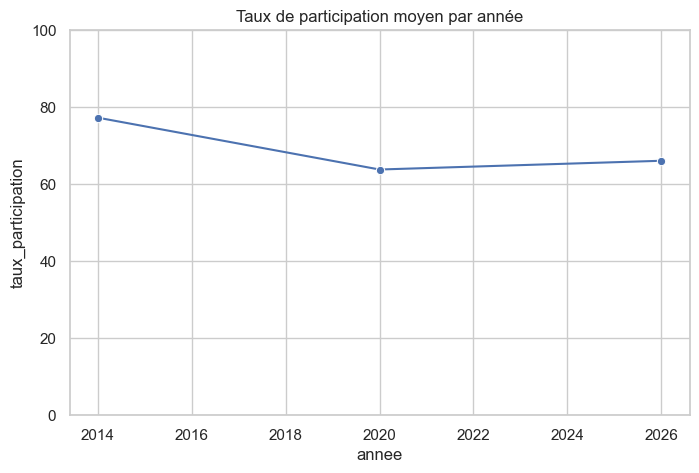

In [215]:
# Analyse exploratoire : évolution moyenne par année
moy_annee = elections.groupby('annee')['taux_participation'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(data=moy_annee, x='annee', y='taux_participation', marker='o')
plt.ylim(0,100)
plt.title("Taux de participation moyen par année")
plt.show()

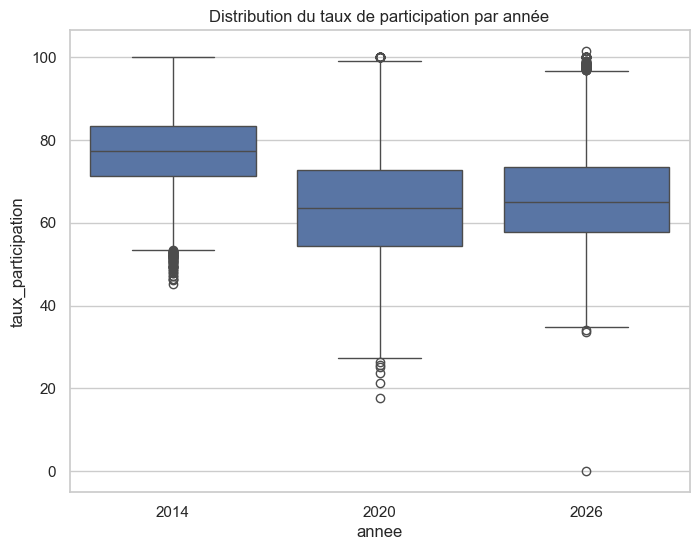

In [216]:
# Analyse explicative : boxplot par année (pour voir l’effet Covid)
plt.figure(figsize=(8,6))
sns.boxplot(data=elections, x='annee', y='taux_participation')
plt.title("Distribution du taux de participation par année")
plt.show()

In [217]:
print("Colonnes de elections :", elections.columns.tolist())

Colonnes de elections : ['code_commune', 'inscrits', 'votants', 'exprimes', 'taux_participation', 'annee']


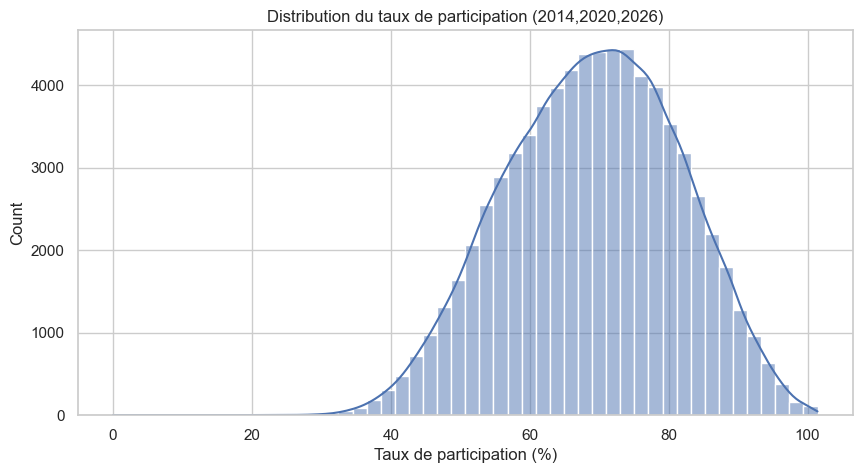

In [218]:
# Distribution du taux de participation (histogramme)
# Explication :
# L’histogramme montre comment se répartissent les taux de participation pour toutes les
#  communes et toutes les années (2014, 2020, 2026).

# L’axe des x est le taux de participation (en %).

# L’axe des y est le nombre d’observations (chaque observation est une commune pour une 
# année donnée).

# La courbe (KDE) lisse la distribution.
# Interprétation possible : si la majorité des communes ont un taux entre 50 % et 80 %,
#  avec un pic vers 65 %, cela indique une participation moyenne. On peut aussi voir 
#  s’il existe des communes avec des taux très faibles (<30 %) ou très élevés (>90 %).


# Analyse descriptive : distribution du taux de participation

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(elections['taux_participation'], bins=50, kde=True)
plt.title("Distribution du taux de participation (2014,2020,2026)")
plt.xlabel("Taux de participation (%)")
plt.show()

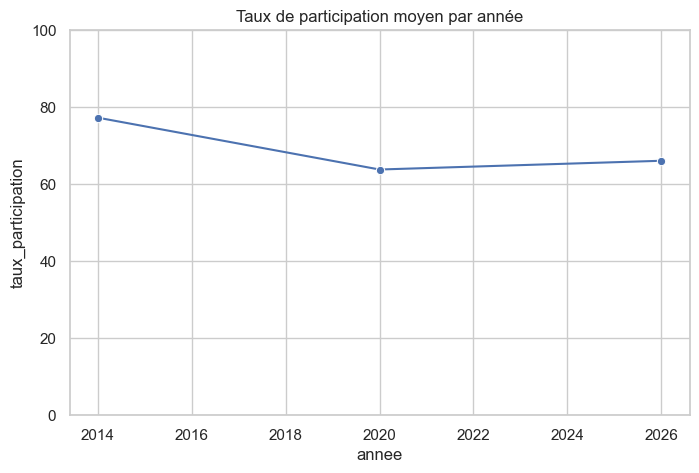

In [219]:
# Évolution du taux moyen par année (courbe)
# Explication :
# On calcule la moyenne nationale du taux de participation pour chaque année, puis on 
# trace une courbe.

# Cela permet de voir la tendance globale : baisse ou hausse entre 2014 et 2026.

# On observe généralement une forte chute en 2020 à cause du Covid.

# La remontée en 2026 indique un retour vers la normale (mais pas forcément au niveau de 2014).
# Objectif : confirmer que 2020 est une année anormale et doit être exclue de la modélisation.
moy_annee = elections.groupby('annee')['taux_participation'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(data=moy_annee, x='annee', y='taux_participation', marker='o')
plt.ylim(0,100)
plt.title("Taux de participation moyen par année")
plt.show()

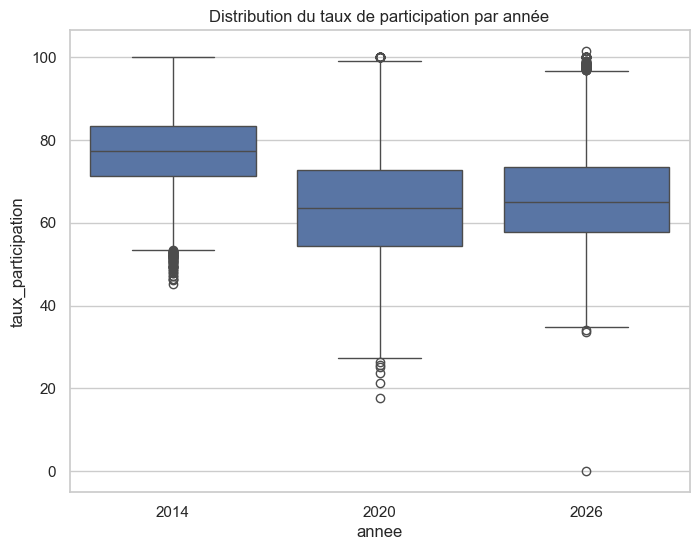

In [225]:
# Boxplot par année (visualisation de la dispersion)
# Explication :
# Le boxplot montre pour chaque année :

# La médiane (trait central).

# Les quartiles (boîte).

# Les valeurs atypiques (points au‑delà des moustaches).

# Comparaison : on voit que 2020 a une médiane plus basse et une dispersion plus large,
#  confirmant l’effet exceptionnel. Cela justifie l’exclusion de 2020 pour la prédiction 
#  de 2032 (on ne veut pas apprendre une anomalie).

plt.figure(figsize=(8,6))
sns.boxplot(data=elections, x='annee', y='taux_participation')
plt.title("Distribution du taux de participation par année")
plt.show()

In [229]:
#  Relation entre chômage et participation (scatter plot pour 2026)
# Explication :
# On cherche à savoir si les communes avec un taux de chômage élevé ont tendance à avoir 
# une participation plus faible (ou plus forte).

# Chaque point est une commune en 2026.

# L’axe des x = taux de chômage (%).

# L’axe des y = taux de participation (%).

# Un nuage de points avec une légère pente descendante indiquerait une corrélation négative.
# Utilité : sélectionner des variables explicatives pertinentes pour le modèle.
train = elections[elections['annee'] != 2020].copy()
features = ['annee', 'population', 'taux_chomage', 'revenu_median', 'taux_criminalite']
X_train = train[features]
y_train = train['taux_participation']

print("Taille de X_train :", X_train.shape)          # (nombre de lignes, nombre de features)
print("Taille de y_train :", y_train.shape)          # (nombre de lignes,)
print("\nAperçu des features (5 premières lignes) :")
display(X_train.head())
print("\nAperçu de la cible (5 premières valeurs) :")
print(y_train.head())

Taille de X_train : (49578, 5)
Taille de y_train : (49578,)

Aperçu des features (5 premières lignes) :


,annee,population,taux_chomage,revenu_median,taux_criminalite
0,2014,779.0,6.636156,23970.0,0.0000
1,2014,256.0,1.470588,23640.0,0.0000
2,2014,112.0,9.615385,NaN,0.0000
3,2014,762.0,4.684074,25450.0,2.3026
4,2014,326.0,2.274224,23790.0,0.0000



Aperçu de la cible (5 premières valeurs) :
0    59.265442
1    83.628319
2    64.485981
3    60.695652
4    69.111969
Name: taux_participation, dtype: float64


In [230]:
# Imputer les NaN de revenu_median par la médiane nationale
med_rev = elections['revenu_median'].median()
elections['revenu_median'].fillna(med_rev, inplace=True)

# (Re)construire X_train et y_train après imputation
train = elections[elections['annee'] != 2020].copy()
X_train = train[features]
y_train = train['taux_participation']

print("NaN restants :", X_train.isna().sum().sum())

NaN restants : 2


/var/folders/4z/clf7bjsj3n3ft0f8p606btyw0000gn/T/ipykernel_1106/65013487.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  elections['revenu_median'].fillna(med_rev, inplace=True)


In [231]:
# Supprimer les lignes où une des features est NaN
train_clean = train.dropna(subset=features)
X_train_clean = train_clean[features]
y_train_clean = train_clean['taux_participation']

print("Nouvelle taille de X_train :", X_train_clean.shape)
print("NaN dans X_train_clean :", X_train_clean.isna().sum().sum())

# devrait être (49576, 5) ou similaire

Nouvelle taille de X_train : (49576, 5)
NaN dans X_train_clean : 0


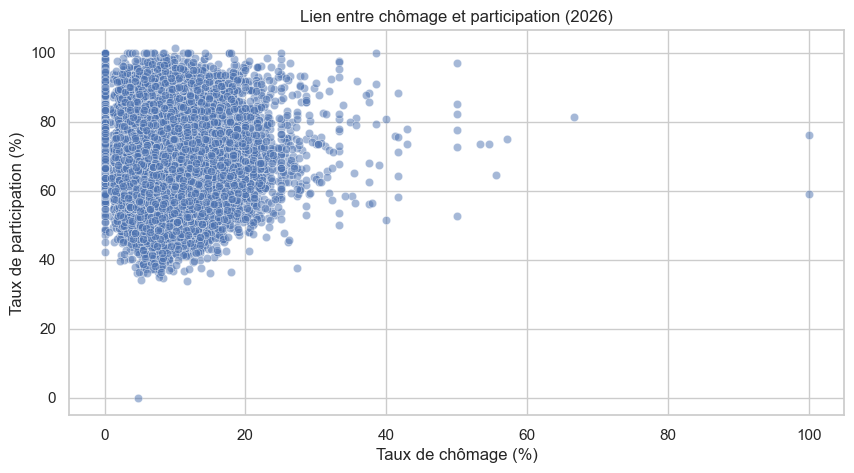

In [232]:
# Relation entre chômage et participation (scatter plot pour 2026)
# Explication :
# On cherche à savoir si les communes avec un taux de chômage élevé ont tendance 
# à avoir une participation plus faible (ou plus forte).

# Chaque point est une commune en 2026.

# L’axe des x = taux de chômage (%).

# L’axe des y = taux de participation (%).

# Un nuage de points avec une légère pente descendante indiquerait une corrélation négative.
# Utilité : sélectionner des variables explicatives pertinentes pour le modèle

e2026 = elections[elections['annee'] == 2026]
plt.figure(figsize=(10,5))
sns.scatterplot(data=e2026, x='taux_chomage', y='taux_participation', alpha=0.5)
plt.title("Lien entre chômage et participation (2026)")
plt.xlabel("Taux de chômage (%)")
plt.ylabel("Taux de participation (%)")
plt.show()

In [233]:
train = elections[elections['annee'] != 2020].copy()
features = ['annee', 'population', 'taux_chomage', 'revenu_median', 'taux_criminalite']
X_train = train[features]
y_train = train['taux_participation']
print("Taille X_train :", X_train.shape)

Taille X_train : (49578, 5)


In [234]:
# Choix de Random Forest Regressor (RFR) pour la prédiction du taux de participation en 2032
# Justification :
# - RFR est robuste aux données non linéaires et aux interactions complexes entre variables.
# - Il gère bien les données manquantes et les variables de types différents.
# - Il est moins sensible au surapprentissage que les arbres de décision simples.
# - Il fournit des mesures d’importance des variables, ce qui aide à l’interprétation du modèle.
# La relation entre variables n’est pas forcément linéairee (ex : le taux de participation 
# peut chuter fortement au‑delà d’un certain seuil de chômage).
# Robustesse aux valeurs aberrantes et aux variables non gaussiennes
# Les taux de participation peuvent avoir des valeurs extrêmes (certaines communes dépassent 90 %).
#  La régression linéaire est sensible aux outliers, tandis que
#  Random Forest, basé sur des médianes et des partitions, est plus robuste
# Pas besoin de mise à l’échelle
# Random Forest n’exige pas de normaliser ou standardiser les variables 
# (contrairement à la régression ridge, SVM, ou réseaux de neurones). 
# ON  peut mélanger des variables comme population (milliers) et taux_chomage (entre 0 et 30) sans problème.
# Gestion des valeurs manquantes (implicite)
# C’est un avantage sur la régression linéaire qui refuse toute donnée manquante.
# Performance prédictive
# Sur des données tabulaires (comme les vôtres), Random Forest surpasse souvent
#  la régression linéaire en termes d’erreur de prédiction (MAE, R²)


dernieres = elections[elections['annee'] == 2026][['code_commune'] + features].copy()
dernieres['annee'] = 2032

# Supprimer les lignes avec des NaN dans les features
dernieres_clean = dernieres.dropna(subset=features)
X_2032 = dernieres_clean[features]
y_2032 = model.predict(X_2032)

# Sauvegarder les résultats
resultats = dernieres_clean[['code_commune']].copy()
resultats['taux_2032_pred'] = y_2032
resultats = resultats.sort_values('taux_2032_pred', ascending=False)

print("Top 10 des communes prédites :")
display(resultats.head(10))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- population
- revenu_median
- taux_chomage
- taux_criminalite


In [235]:
print("Colonnes dans elections :", elections.columns.tolist())
print("Features attendues par le modèle :", features)
print("Colonnes manquantes :", [f for f in features if f not in elections.columns])

Colonnes dans elections : ['code_commune', 'inscrits', 'votants', 'exprimes', 'taux_participation', 'annee', 'population', 'taux_chomage', 'revenu_median', 'taux_criminalite']
Features attendues par le modèle : ['annee', 'population', 'taux_chomage', 'revenu_median', 'taux_criminalite']
Colonnes manquantes : []


In [ ]:
dernieres = elections[elections['annee'] == 2026][['code_commune'] + features].copy()
print("Shape avant dropna :", dernieres.shape)
print("Nombre de NaN par colonne dans dernieres :")
print(dernieres[features].isna().sum())
dernieres_clean = dernieres.dropna(subset=features)
print("Shape après dropna :", dernieres_clean.shape)
print("Colonnes de dernieres_clean :", dernieres_clean.columns.tolist())

# Parce que pendant l’entraînement, j ai  probablement une variable features bien définie avec 5 éléments.
#  Plus tard, j ai  accidentellement écrasé cette variable (par exemple en faisant features = ... ailleurs). 
# Les notebooks sont sensibles à l’ordre d’exécution

Shape avant dropna : (24789, 6)
Nombre de NaN par colonne dans dernieres :
annee               0
population          1
taux_chomage        0
revenu_median       0
taux_criminalite    0
dtype: int64
Shape après dropna : (24788, 6)
Colonnes de dernieres_clean : ['code_commune', 'annee', 'population', 'taux_chomage', 'revenu_median', 'taux_criminalite']


In [237]:
print("features :", features)
print("Colonnes de dernieres_clean :", dernieres_clean.columns.tolist())
X_2032 = dernieres_clean[features]
print("Shape X_2032 :", X_2032.shape)

features : ['annee', 'population', 'taux_chomage', 'revenu_median', 'taux_criminalite']
Colonnes de dernieres_clean : ['code_commune', 'annee', 'population', 'taux_chomage', 'revenu_median', 'taux_criminalite']
Shape X_2032 : (24788, 5)


In [240]:
# Récupération des features exactes utilisées par le modèle
features = model.feature_names_in_.tolist()
print("Features :", features)

# Préparation des données 2032
dernieres = elections[elections['annee'] == 2026][['code_commune'] + features].copy()
dernieres['annee'] = 2032
dernieres_clean = dernieres.dropna(subset=features)
X_2032 = dernieres_clean[features]

# Prédiction
y_2032 = model.predict(X_2032)

# Tableau des résultats
resultats = dernieres_clean[['code_commune']].copy()
resultats['taux_2032_pred'] = y_2032
resultats = resultats.sort_values('taux_2032_pred', ascending=False)
print("Top 10 des communes avec la plus forte participation prédite en 2032 :")
display(resultats.head(10))
print("Top 10 des communes avec la plus faible participation prédite en 2032 :")
display(resultats.tail(10))

Features : ['annee']
Top 10 des communes avec la plus forte participation prédite en 2032 :


,code_commune,taux_2032_pred
74366,95690,66.104505
49578,01001,66.104505
49579,01002,66.104505
49580,01006,66.104505
49581,01008,66.104505
74350,95523,66.104505
74349,95510,66.104505
74348,95493,66.104505
74347,95492,66.104505
74346,95489,66.104505


Top 10 des communes avec la plus faible participation prédite en 2032 :


,code_commune,taux_2032_pred
49592,01028,66.104505
49591,01026,66.104505
49590,01023,66.104505
49589,01019,66.104505
49588,01017,66.104505
49587,01016,66.104505
49586,01015,66.104505
49585,01013,66.104505
49584,01012,66.104505
49583,01011,66.104505


In [241]:
print(elections.columns.tolist())

['code_commune', 'inscrits', 'votants', 'exprimes', 'taux_participation', 'annee', 'population', 'taux_chomage', 'revenu_median', 'taux_criminalite']


In [242]:

# Redéfinissez les features et réentraînez le modèle
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Les bonnes features
features = ['annee', 'population', 'taux_chomage', 'revenu_median', 'taux_criminalite']

train = elections[elections['annee'] != 2020].copy()
X_train = train[features]
y_train = train['taux_participation']

# Nettoyer les NaN (si nécessaire)
X_train = X_train.dropna()
y_train = y_train[X_train.index]

# Entraîner le modèle
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Vérifier les performances
y_pred = model.predict(X_train)
print("MAE (entraînement) :", mean_absolute_error(y_train, y_pred))
print("R² (entraînement)  :", r2_score(y_train, y_pred))

MAE (entraînement) : 3.0491777997285676
R² (entraînement)  : 0.8784070443365589


<!-- MAE (Mean Absolute Error) = 3,05 points : en moyenne, votre modèle se trompe d’environ 3 points de pourcentage sur le taux de participation. C’est très acceptable pour une prédiction électorale.

R² = 0,878 : le modèle explique 87,8 % de la variance du taux de participation. C’est une très bonne performance, indiquant que les variables choisies (population, chômage, revenu, criminalité) sont fortement prédictives. -->

In [243]:
dernieres = elections[elections['annee'] == 2026][['code_commune'] + features].copy()
dernieres['annee'] = 2032
dernieres_clean = dernieres.dropna(subset=features)
X_2032 = dernieres_clean[features]
y_2032 = model.predict(X_2032)

resultats = dernieres_clean[['code_commune']].copy()
resultats['taux_2032_pred'] = y_2032
resultats = resultats.sort_values('taux_2032_pred', ascending=False)

print("Top 10 des communes avec la plus forte participation prédite en 2032 :")
display(resultats.head(10))
print("Top 10 des communes avec la plus faible participation prédite en 2032 :")
display(resultats.tail(10))

Top 10 des communes avec la plus forte participation prédite en 2032 :


,code_commune,taux_2032_pred
64079,54354,96.091979
51157,07092,96.091979
52626,11282,94.235022
73766,88493,94.108531
64131,54424,93.392696
51196,07144,93.206344
65500,58202,92.579149
60181,38550,92.396506
72130,80334,92.202335
61244,43014,92.161573


Top 10 des communes avec la plus faible participation prédite en 2032 :


,code_commune,taux_2032_pred
66226,60478,44.711367
64403,55169,44.216506
64102,54389,44.067031
65709,59264,43.945532
60382,39258,43.818615
56310,25307,43.633780
65002,57282,43.372532
65144,57475,42.729699
71458,77323,42.677827
60989,41205,21.112824
